In [59]:
from bs4 import BeautifulSoup
from selenium import webdriver
import re
import pandas as pd
from sklearn.preprocessing import LabelEncoder

**Scrape the Webpage**

In [4]:
# Selenium
options = webdriver.ChromeOptions()
options.add_argument('--headless')  # Run Chrome in headless mode
options.add_argument("--no-sandbox")  # Bypass OS security model
options.add_argument("--disable-dev-shm-usage")  # Overcome limited resource problems

# For not being consider as a bot
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.5481.178 Safari/537.36")

driver = webdriver.Chrome(options=options)

url = "https://www.bbc.com/weather/293397"
driver.get(url)

# Parse the HTML
soup = BeautifulSoup(driver.page_source, 'html.parser')
driver.quit()


In [52]:
# All daily forecast
forecasts = soup.find_all("li", class_="wr-day")

if not forecasts:
    print("No weather data found! The site may be blocking bots.")
    exit()

# List to store data
weather_data = []

for forecast in forecasts:
  # Date
  date_tag = forecast.find("div", class_="wr-day__title")
  date = date_tag.text.strip() if date_tag else "N/A"

  # Temperature
  temp_max_tag = forecast.find("span", class_="wr-value--temperature--c")
  temp_max = temp_max_tag.text.strip().replace("°", "") if temp_max_tag else "N/A"

  # Weather Condition
  condition_tag = forecast.find("div", class_="wr-day__details__weather-type-description")
  weather_condition = condition_tag.text.strip() if condition_tag else "N/A"


  # Add data
  weather_data.append({
      "Date": date,
      "Max Temperature (°C)": temp_max,
      "Weather Condition": weather_condition})



**Data Analysis with Pandas:**

- Load your scraped data into a Pandas DataFrame.

In [53]:
df = pd.DataFrame(weather_data)
df

,Date,Max Temperature (°C),Weather Condition
0,Tonight,15,Light rain showers and a moderate breeze
1,Thursday 20th MarchThu 20th,17,Thundery showers and a fresh breeze
2,Friday 21st MarchFri 21st,16,Light rain and a gentle breeze
3,Saturday 22nd MarchSat 22nd,17,Light rain and a gentle breeze
4,Sunday 23rd MarchSun 23rd,19,Sunny and a gentle breeze
5,Monday 24th MarchMon 24th,20,Sunny and a gentle breeze
6,Tuesday 25th MarchTue 25th,22,Sunny and a gentle breeze
7,Wednesday 26th MarchWed 26th,24,Sunny and a gentle breeze
8,Thursday 27th MarchThu 27th,27,Sunny and light winds
9,Friday 28th MarchFri 28th,27,Sunny and a gentle breeze


- Clean and preprocess the data if necessary (handling missing values, type conversion, etc.).

In [54]:
# Missing values
df.isnull().sum()

,0
Date,0
Max Temperature (°C),0
Weather Condition,0


In [55]:
df.describe()

,Date,Max Temperature (°C),Weather Condition
count,14,14,14
unique,14,10,5
top,Tonight,17,Sunny and a gentle breeze
freq,1,2,9


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Date                  14 non-null     object
 1   Max Temperature (°C)  14 non-null     object
 2   Weather Condition     14 non-null     object
dtypes: object(3)
memory usage: 468.0+ bytes


In [57]:
# Converting Temperature object into int
df['Max Temperature (°C)'] = df['Max Temperature (°C)'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Date                  14 non-null     object
 1   Max Temperature (°C)  14 non-null     int64 
 2   Weather Condition     14 non-null     object
dtypes: int64(1), object(2)
memory usage: 468.0+ bytes


In [65]:
# Encoding Weather Condition into categorical values
label_encoder = LabelEncoder()

df["Weather Encoded"] = label_encoder.fit_transform(df["Weather Condition"])


In [66]:
df

,Date,Max Temperature (°C),Weather Condition,Weather Encoded
0,Tonight,15,Light rain showers and a moderate breeze,1
1,Thursday 20th MarchThu 20th,17,Thundery showers and a fresh breeze,4
2,Friday 21st MarchFri 21st,16,Light rain and a gentle breeze,0
3,Saturday 22nd MarchSat 22nd,17,Light rain and a gentle breeze,0
4,Sunday 23rd MarchSun 23rd,19,Sunny and a gentle breeze,2
5,Monday 24th MarchMon 24th,20,Sunny and a gentle breeze,2
6,Tuesday 25th MarchTue 25th,22,Sunny and a gentle breeze,2
7,Wednesday 26th MarchWed 26th,24,Sunny and a gentle breeze,2
8,Thursday 27th MarchThu 27th,27,Sunny and light winds,3
9,Friday 28th MarchFri 28th,27,Sunny and a gentle breeze,2


- Perform basic analysis, such as calculating averages, totals, or trends over time.

In [68]:
# Average Temperature
average_temp = df["Max Temperature (°C)"].mean()
print(f"Average Temperature on the 2 next weeks: {average_temp:.2f}°C")

Average Temperature on the 2 next weeks: 21.36°C


In [75]:
# Trends
most_common_condition = df["Weather Condition"].value_counts().idxmax()
print(f"The most common weather condition will be: {most_common_condition}")

The most common weather condition will be: Sunny and a gentle breeze


**Data Visualization with Seaborn and Matplotlib:**





In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

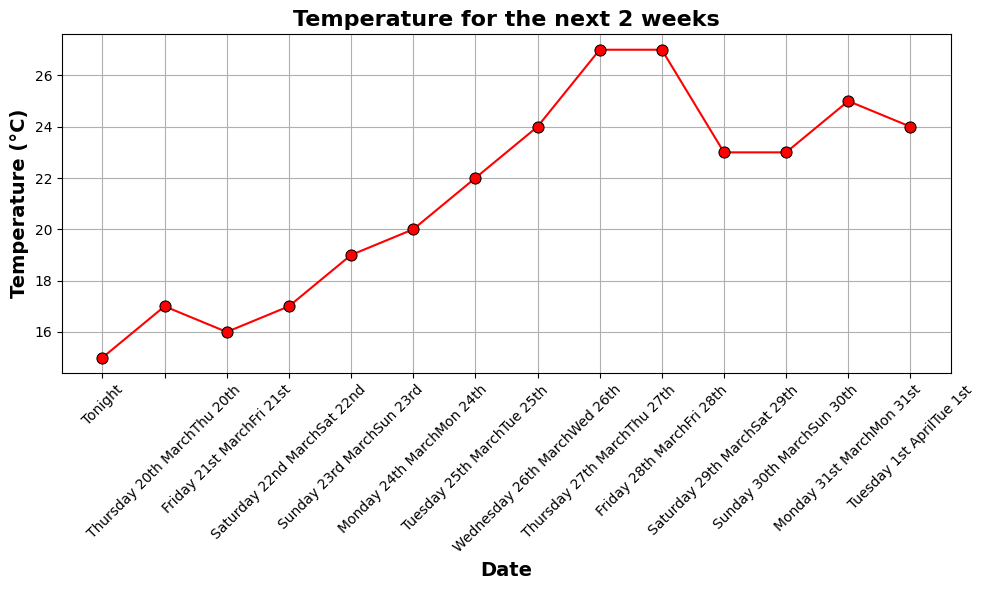

In [93]:
# Temperature over time
plt.figure(figsize=(10, 6))

sns.lineplot(data=df, x="Date", y="Max Temperature (°C)", color='r', marker='o', markeredgecolor='black', markersize=8)
plt.title("Temperature for the next 2 weeks", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=14, fontweight='bold')
plt.ylabel("Temperature (°C)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)

plt.show()

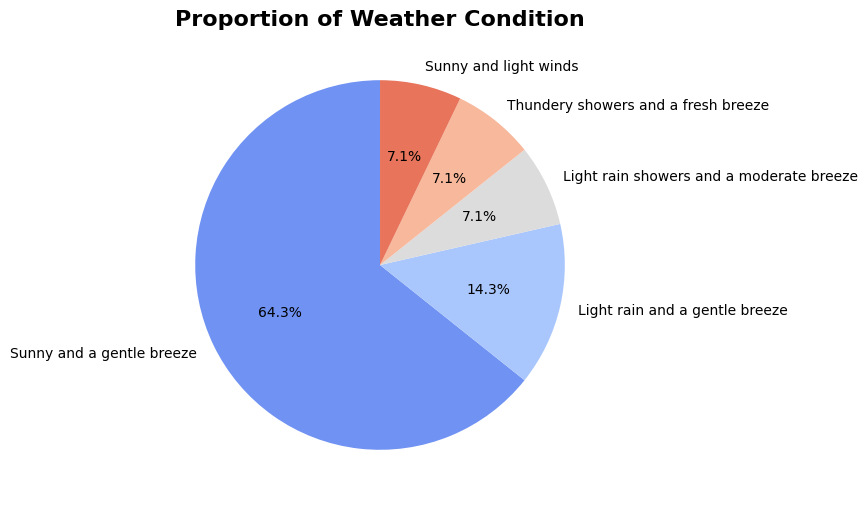

In [106]:
# Trends
condition_counts = df["Weather Condition"].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(condition_counts, labels=condition_counts.index, autopct="%1.1f%%", colors=sns.color_palette("coolwarm", len(condition_counts)), startangle=90)

plt.title("Proportion of Weather Condition", fontsize=16, fontweight='bold')

plt.show()

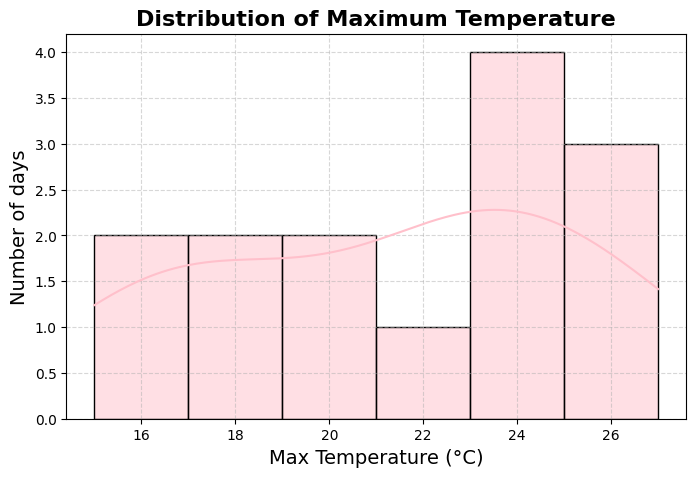

In [116]:
# Histogramme
plt.figure(figsize=(8, 5))
sns.histplot(df["Max Temperature (°C)"], bins=6, kde=True, color="pink")

plt.title("Distribution of Maximum Temperature", fontsize=16, fontweight="bold")
plt.xlabel("Max Temperature (°C)", fontsize=14)
plt.ylabel("Number of days", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


**Document Your Findings:**

- **Scraping the Data:**
  - Weather data was extracted from *BBC Weather - Tel Aviv* using **Selenium and BeautifulSoup**.
  - The extracted information includes:
    - The maximum temperature forecasted for the next 14 days.
    - The weather conditions associated with each day.
  - In order to analyse our data, we loaded them into a Pandas DataFrame.

- **Data Analysis with Pandas:**
  - We ensure there were no missing values.
  - We encoded categorical weather conditions into numerical values for further analysis.

- **Data Visualization with Seaborn and Matplotlib:**
  - **Line plot**: The temperature is expected to rise until **Thursday, March 27th**, reaching a peak of **27°C**, followed by a slight decrease between **23°C** and **24°C**.
  - **Pie chart**: The most common weather condition over the next two weeks is *"Sunny and a gentle breeze"*.
  - **Histogramme**:  The most frequently occurring temperature will be **24°C** over the next few days.

This analysis provides insights into the expected weather trends in Tel Aviv, allowing for better planning based on temperature fluctuations and common weather conditions.